# 第7回課題: 適用ドメイン (Applicability Domain)

`boston.csv` の `MEDV` を目的変数として回帰モデルを作成し、Hold-Out 検証で得られたテストデータが適用ドメイン (AD) 内か外かを判定します。

このノートブックでは、標準化した説明変数空間における **Euclidean距離** を使い、学習データ同士の **5近傍平均距離の95パーセンタイル** をADしきい値とします。テストデータの5近傍平均距離がしきい値以下ならAD内、しきい値より大きければAD外と判定します。

## 1. ライブラリの読み込み

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42

## 2. データの読み込み

`MEDV` を目的変数、それ以外の列を説明変数として扱います。

In [2]:
data_path = Path("boston.csv")
df = pd.read_csv(data_path, index_col=0)

display(df.head())
print(f"データ数: {df.shape[0]}")
print(f"列数: {df.shape[1]}")
print(f"欠損値数: {int(df.isna().sum().sum())}")

,MEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
sample_1,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
sample_2,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
sample_3,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
sample_4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
sample_5,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


データ数: 506
列数: 14
欠損値数: 0


In [3]:
target_col = "MEDV"

X = df.drop(columns=target_col)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"学習データ数: {len(X_train)}")
print(f"テストデータ数: {len(X_test)}")

学習データ数: 379
テストデータ数: 127


## 3. 前処理と回帰モデル

距離計算にスケールの影響が出るため、説明変数は学習データで標準化します。回帰モデルには `RandomForestRegressor` を使用します。

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Hold-Out 検証の予測性能")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2 : {r2:.3f}")

Hold-Out 検証の予測性能
MAE : 2.176
RMSE: 3.359
R^2 : 0.839


## 4. kNNによるADしきい値の計算

- 距離空間: 標準化した説明変数空間
- 距離指標: Euclidean距離
- k: 5
- しきい値: 学習データ同士の5近傍平均距離の95パーセンタイル

学習データ同士で近傍を取ると自分自身の距離0が含まれるため、`k + 1` 近傍を取得して自分自身を除外します。

In [5]:
k = 5
percentile = 95
metric = "euclidean"

nn = NearestNeighbors(n_neighbors=k + 1, metric=metric)
nn.fit(X_train_scaled)

# 訓練データ同士: 0列目は自分自身への距離0なので除外
train_distances, _ = nn.kneighbors(X_train_scaled)
train_knn_mean_distance = train_distances[:, 1:].mean(axis=1)
ad_threshold = np.percentile(train_knn_mean_distance, percentile)

# テストデータ: 自分自身は含まれないので先頭k列をそのまま使用
test_distances, _ = nn.kneighbors(X_test_scaled)
test_knn_mean_distance = test_distances[:, :k].mean(axis=1)

is_in_ad = test_knn_mean_distance <= ad_threshold

print(f"k = {k}")
print(f"距離指標 = {metric}")
print(f"ADしきい値 ({percentile}パーセンタイル) = {ad_threshold:.3f}")
print(f"AD内のテストデータ数: {int(is_in_ad.sum())}")
print(f"AD外のテストデータ数: {int((~is_in_ad).sum())}")

k = 5
距離指標 = euclidean
ADしきい値 (95パーセンタイル) = 2.435
AD内のテストデータ数: 123
AD外のテストデータ数: 4


## 5. テストデータごとのAD判定と誤差

In [6]:
results = pd.DataFrame(
    {
        "actual_MEDV": y_test,
        "predicted_MEDV": y_pred,
        "residual": y_test.to_numpy() - y_pred,
        "abs_error": np.abs(y_test.to_numpy() - y_pred),
        "knn_mean_distance": test_knn_mean_distance,
        "AD": np.where(is_in_ad, "inside", "outside"),
    },
    index=y_test.index,
)

display(results.sort_values("knn_mean_distance", ascending=False).head(10))

,actual_MEDV,predicted_MEDV,residual,abs_error,knn_mean_distance,AD
sample_419,8.8,8.636572,0.163428,0.163428,4.468247,outside
sample_415,7.0,8.191521,-1.191521,1.191521,3.923629,outside
sample_366,27.5,23.691086,3.808914,3.808914,2.766839,outside
sample_413,17.9,11.295440,6.604560,6.604560,2.757102,outside
sample_418,10.4,7.984463,2.415537,2.415537,2.092083,inside
sample_356,20.6,21.899035,-1.299035,1.299035,1.959757,inside
sample_399,5.0,7.220216,-2.220216,2.220216,1.857209,inside
sample_210,20.0,16.976068,3.023932,3.023932,1.799101,inside
sample_376,15.0,30.071441,-15.071441,15.071441,1.744267,inside
sample_205,50.0,44.922911,5.077089,5.077089,1.719813,inside


In [7]:
summary_by_ad = (
    results.groupby("AD")
    .agg(
        n=("actual_MEDV", "size"),
        MAE=("abs_error", "mean"),
        RMSE=("residual", lambda x: np.sqrt(np.mean(x**2))),
        mean_knn_distance=("knn_mean_distance", "mean"),
    )
    .sort_index()
)

display(summary_by_ad)

,n,MAE,RMSE,mean_knn_distance
AD,,,,
inside,123,2.150644,3.341490,1.087938
outside,4,2.942106,3.859225,3.478954


## 6. 可視化1: 学習データ間の平均距離分布とADしきい値

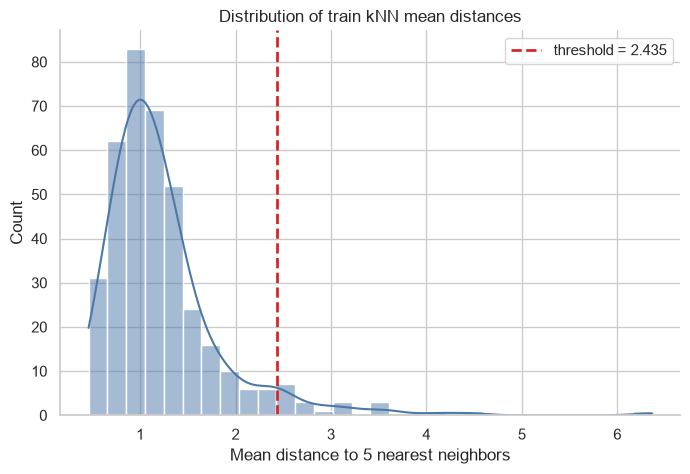

In [8]:
fig, ax = plt.subplots()

sns.histplot(train_knn_mean_distance, bins=30, kde=True, color="#4C78A8", ax=ax)
ax.axvline(ad_threshold, color="#D62728", linestyle="--", linewidth=2, label=f"threshold = {ad_threshold:.3f}")
ax.set_title("Distribution of train kNN mean distances")
ax.set_xlabel("Mean distance to 5 nearest neighbors")
ax.set_ylabel("Count")
ax.legend()

plt.show()

## 7. 可視化2: テストデータのk近傍距離と予測誤差

横軸がAD判定に使ったテストデータの5近傍平均距離、縦軸が絶対誤差です。赤い破線より右側はAD外です。

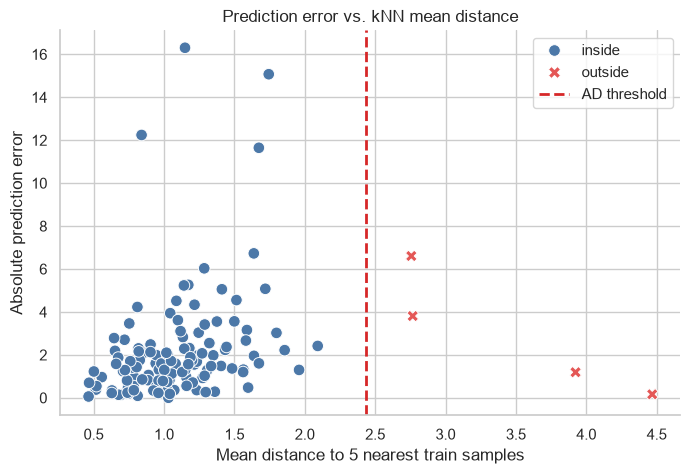

In [9]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=results,
    x="knn_mean_distance",
    y="abs_error",
    hue="AD",
    style="AD",
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=70,
    ax=ax,
)
ax.axvline(ad_threshold, color="#D62728", linestyle="--", linewidth=2, label="AD threshold")
ax.set_title("Prediction error vs. kNN mean distance")
ax.set_xlabel("Mean distance to 5 nearest train samples")
ax.set_ylabel("Absolute prediction error")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title=None)

plt.show()

## 8. 予測値の信頼性の可視化

実測値と予測値の散布図をAD判定で色分けします。AD外の点は学習データから離れた外挿領域にあるため、予測値の信頼性が相対的に低いと考えられます。

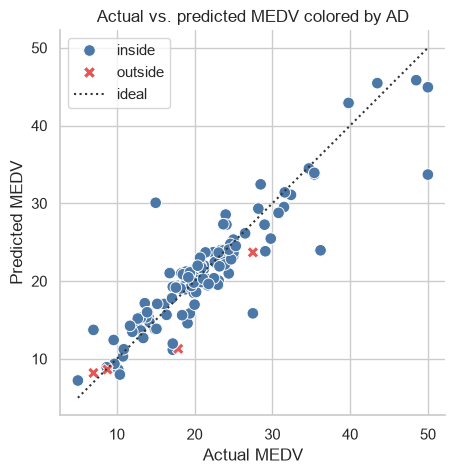

In [10]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=results,
    x="actual_MEDV",
    y="predicted_MEDV",
    hue="AD",
    style="AD",
    palette={"inside": "#4C78A8", "outside": "#E45756"},
    s=70,
    ax=ax,
)

min_value = min(results["actual_MEDV"].min(), results["predicted_MEDV"].min())
max_value = max(results["actual_MEDV"].max(), results["predicted_MEDV"].max())
ax.plot([min_value, max_value], [min_value, max_value], color="#333333", linestyle=":", label="ideal")
ax.set_title("Actual vs. predicted MEDV colored by AD")
ax.set_xlabel("Actual MEDV")
ax.set_ylabel("Predicted MEDV")
ax.set_aspect("equal", adjustable="box")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title=None)

plt.show()

## 9. AD外サンプルの確認

In [11]:
outside_ad = results[results["AD"] == "outside"].sort_values("knn_mean_distance", ascending=False)

if outside_ad.empty:
    print("このHold-Out分割ではAD外と判定されたテストデータはありませんでした。")
else:
    display(outside_ad)
    print(
        f"AD外サンプルのMAEは {outside_ad['abs_error'].mean():.3f} で、"
        f"全テストデータのMAE {mae:.3f} と比較して予測信頼性を確認できます。"
    )

,actual_MEDV,predicted_MEDV,residual,abs_error,knn_mean_distance,AD
sample_419,8.8,8.636572,0.163428,0.163428,4.468247,outside
sample_415,7.0,8.191521,-1.191521,1.191521,3.923629,outside
sample_366,27.5,23.691086,3.808914,3.808914,2.766839,outside
sample_413,17.9,11.295440,6.604560,6.604560,2.757102,outside


AD外サンプルのMAEは 2.942 で、全テストデータのMAE 2.176 と比較して予測信頼性を確認できます。


## 10. まとめ

- `MEDV` を目的変数としてHold-Out検証による回帰モデルを作成した。
- 標準化した説明変数空間でEuclidean距離を計算し、学習データの5近傍平均距離の95パーセンタイルをADしきい値とした。
- テストデータの5近傍平均距離をしきい値と比較し、AD内・AD外を判定した。
- AD外の点は学習データから離れた外挿領域にあるため、予測値の信頼性が相対的に低いサンプルとして扱える。